# Ablations 4.3.2 + 4.3.3 — Cropping policy & Augmentation

**Thesis:** *Concept dataset extraction for Concept Activation Vectors: A study on open-vocabulary grounding and segmentation*  
**Author:** Alessandro Cogollo (233022)  
**Advisor:** Prof. Marco Brambilla — **Co-advisors:** A. De Santis, M. Bianchi, R. Campi  
**Academic year:** 2025-2026

**Maps to:** Thesis §4.3.2 (*Cropping strategies*) and §4.3.3 (*Augmented vs. Vanilla*); produces the panels of Thesis **Figure 19** and the Executive-Summary RQ4 ablation numbers.

## Purpose
Single notebook that recomputes the exp-1.1 / exp-2.1 metric families and compares them across the two dataset variants (**vanilla vs. augmented**) and the four cropping policies (`bbox`, `center_mask`, `largest_bbox`, `sliding_window`).

## Metrics (per `source × crop_method × concept`)
VLM-as-judge alignment (mean/std, %<0.25, P@0.5, P@0.7), CLIP repetition rate & participation ratio, and difference-of-means **CAV cosine** (auto ↔ manual) averaged over the ResNet-50 layers.

## Outputs (`/kaggle/working/exp_summary_output`)
`summary_metrics_cells.csv`, `summary_metrics_layers.csv`, `summary_by_source.csv`, `summary_by_crop.csv`, `fig1_vanilla_vs_augmented.png`, `fig2_cropping_policies.png`.

## How to run
Run top-to-bottom on Kaggle with the auto-concept crops, DTD/T2I manual sets and the negative pool attached. The VLM judge dominates runtime — keep `max_vlm_images` modest for a smoke run.

## ⚠️ Notes for reviewers
- **Negative pool.** Headline numbers use `negative_kind='full'` (full-scene VTCAV `/random` negatives), consistent with the thesis. Because positives are texture *crops*, a shared *texture-vs-scene* axis can inflate the absolute CAV cosine; treat those values as an **upper bound**. The notebook also exposes `negative_kind='cropped'` (in-domain negatives) — this is the leave-one-out variant discussed in Thesis §5.2 (limitations) / §5.3 (future work) and is **not** part of the reported headline ablation.
- **CAV cosine, vanilla vs augmented.** On the aggregate-by-source the two are within noise (≈0.435 vs ≈0.420); the augmentation benefit on CAV similarity is **policy-dependent**, not systematic — phrase any claim accordingly.

# Experiment Summary — Dataset Quality & Concept Faithfulness across Pipelines

**Goal.** Pull together, in a single notebook, the metric families used in
experiments 1.1 / 2.1 and compare them across the two dataset variants
(**vanilla vs. augmented**) and the four **cropping policies**
(`bbox`, `center_mask`, `largest_bbox`, `sliding_window`).

### Metrics computed (per `auto_source × crop_method × concept`)

| Family | Metric | Source notebook | Direction |
|--------|--------|-----------------|-----------|
| VLM-as-judge | **VLM Alignment — Mean** / **Std** of `P(yes)` | exp 1.1 | mean ↑ / std ↓ |
| Embedding quality | **Repetition Rate** (CLIP near-dup %) | exp 1.1 | ↓ |
| Embedding quality | **Participation Ratio** (CLIP diversity) | exp 1.1 | ↑ |
| Concept direction | **CAV cosine** (auto-CAV vs. manual-CAV) | exp 2.1 | ↑ |

* **VLM judge** — `Qwen2-VL-2B-Instruct`, logit-based `P(yes)` (exp 1.1).
* **Repetition / Participation** — frozen CLIP `ViT-B-32` embeddings (exp 1.1).
* **CAV cosine** — difference-of-means CAV in standardized space, scaler fit on
  the shared negative pool; cosine of auto vs. manual direction (exp 2.1).

> **Orthogonal concepts.** `fibrous` and `veined` pool their `base` **and**
> `random` splits into a single positive image set; every other concept uses
> the single `base` split.

### Two output figures
1. **Vanilla vs. Augmented** — one panel per metric, bars = source (aggregated
   over crop policies + concepts).
2. **Cropping policies** — one panel per metric, bars = crop method, grouped by
   source (aggregated over concepts).

> ⚠️ **Negative-pool note (reviewer-facing).** Headline numbers use `negative_kind='full'` (full-scene `/random` negatives), as in the thesis. Since positives are texture crops, the shared *texture-vs-scene* axis can inflate the absolute CAV cosine — read those values as an **upper bound**. `negative_kind='cropped'` gives the in-domain (leave-one-out) variant; it is the future-work direction of Thesis §5.3 and is **not** part of the reported ablation.


In [62]:
# ─── Install dependencies ─────────────────────────────────────────────────────
!pip install -q open_clip_torch "transformers>=4.45" accelerate matplotlib "seaborn>=0.13" scikit-learn pandas tqdm

In [63]:
import os
import json
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial.distance import cosine as cosine_dist

import torch
import torch.nn as nn
import torchvision.models as tv_models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ─── Reproducibility ──────────────────────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
print('PyTorch:', torch.__version__)

Device : cuda
PyTorch: 2.10.0+cu128


## Network Registry (ResNet50 · VGG16 · InceptionV3)
In-place ReLUs are disabled so the forward activation hooks behave consistently
(matches exp 3.1).


In [64]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def _disable_inplace(m: nn.Module) -> nn.Module:
    for mod in m.modules():
        if hasattr(mod, 'inplace'):
            mod.inplace = False
    return m


def _resnet50_loader():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    return _disable_inplace(m).eval()


def _vgg16_loader():
    m = tv_models.vgg16(weights=tv_models.VGG16_Weights.IMAGENET1K_V1)
    return _disable_inplace(m).eval()


def _inception_v3_loader():
    m = tv_models.inception_v3(
        weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
    m.aux_logits = False
    m.AuxLogits = None
    return _disable_inplace(m).eval()


MODEL_REGISTRY: Dict[str, Dict] = {
    'resnet50': {
        'loader':        _resnet50_loader,
        'img_size':      224,
        'target_layers': ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2'],
        'layer_dims':    {'layer1.2': 256, 'layer2.3': 512,
                          'layer3.5': 1024, 'layer4.2': 2048},
    },
    'vgg16': {
        'loader':        _vgg16_loader,
        'img_size':      224,
        'target_layers': ['features.8', 'features.15', 'features.22', 'features.29'],
        'layer_dims':    {'features.8': 128, 'features.15': 256,
                          'features.22': 512, 'features.29': 512},
    },
    'inception_v3': {
        'loader':        _inception_v3_loader,
        'img_size':      299,
        'target_layers': ['Mixed_5d', 'Mixed_6c', 'Mixed_6e', 'Mixed_7c'],
        'layer_dims':    {'Mixed_5d': 288, 'Mixed_6c': 768,
                          'Mixed_6e': 768, 'Mixed_7c': 2048},
    },
}


def build_transform(img_size: int) -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


print('Model registry ready ✓  ', list(MODEL_REGISTRY.keys()))

Model registry ready ✓   ['resnet50', 'vgg16', 'inception_v3']


## Configuration
The comparison axes (`auto_sources`, `crop_methods`), the fixed `split`, the
backbone used for the CAV and the image caps all live here. The CAV uses
**average pooling only** (matching exp 2.1), so each layer yields one CAV.


In [65]:
@dataclass
class Config:
    # ── Comparison axes ─────────────────────────────────────────────
    auto_sources: List[str] = field(default_factory=lambda: ['vanilla', 'augmented'])
    crop_methods: List[str] = field(default_factory=lambda: [
        'bbox', 'center_mask', 'largest_bbox', 'sliding_window'])
    split: str = 'base'          # single representative split for the grid
    concepts: List[str] = field(default_factory=lambda: [
        'striped', 'dotted', 'chequered', 'wood', 'water', 'braided', 'bubbly',
        'fibrous', 'veined'])

    # ── Backbone for the CAV ───────────────────────────────────────
    model_name: str = 'resnet50'   # 'resnet50' | 'vgg16' | 'inception_v3'

    # ── Negatives ───────────────────────────────────────────────
    negative_kind: str = 'full'    # 'full' (scene imgs) | 'cropped' (in-domain)

    # ── Sampling / caps (keep modest — the VLM judge is the slow part) ─────
    max_auto_images:   int = 100   # imgs per auto concept dir (CLIP + activations)
    max_vlm_images:    int = 60    # imgs per auto concept dir for the VLM judge
    max_manual_images: int = 100
    max_negative_pool: int = 300
    batch_size:        int = 32

    # ── Metric params ──────────────────────────────────────────
    threshold_repetition: float = 0.95
    threshold_alignment:  float = 0.25

    # ── Models ─────────────────────────────────────────────────
    clip_model_name: str = 'ViT-B-32'
    clip_pretrained: str = 'openai'
    vlm_model_id:    str = 'Qwen/Qwen2-VL-2B-Instruct'

    output_dir: str = '/kaggle/working/exp_summary_output'

    # Derived at backbone-switch time
    img_size: int = 224
    target_layers: List[str] = field(default_factory=list)


cfg = Config()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

preset = MODEL_REGISTRY[cfg.model_name]
cfg.target_layers = preset['target_layers']
cfg.img_size = preset['img_size']

print('Configuration loaded ✓')
print(f'  Backbone     : {cfg.model_name}  (img_size={cfg.img_size})')
print(f'  Layers       : {cfg.target_layers}')
print(f'  Sources      : {cfg.auto_sources}')
print(f'  Crop methods : {cfg.crop_methods}')
print(f'  Split        : {cfg.split}')
print(f'  Concepts     : {cfg.concepts}')
print(f'  Negatives    : {cfg.negative_kind}')


Configuration loaded ✓
  Backbone     : resnet50  (img_size=224)
  Layers       : ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2']
  Sources      : ['vanilla', 'augmented']
  Crop methods : ['bbox', 'center_mask', 'largest_bbox', 'sliding_window']
  Split        : base
  Concepts     : ['striped', 'dotted', 'chequered', 'wood', 'water', 'braided', 'bubbly', 'fibrous', 'veined']
  Negatives    : full


## Dataset Layout & Path Resolution  ·  *matches exp 1.1 / 2.1 / 3.1*
Automatic concepts: `crops/{pipeline}/{pipeline}_{crop_method}/{concept}/{split}/`
(with `augmented`/`augmentation` aliases). Manual baselines: DTD-Concept / DTD /
T2I, first existing non-empty candidate wins.

In [66]:
def _resolve_root(*candidates: str) -> str:
    """First existing path among candidates (Kaggle mounts vary)."""
    for c in candidates:
        if Path(c).exists():
            return c
    return candidates[0]


ACG_ROOT = _resolve_root(
    '/kaggle/input/datasets/alessandrocogollo/acg4cav-extracted-concepts/crops',
    '/kaggle/input/acg4cav-extracted-concepts/crops')
VTCAV_ROOT = _resolve_root(
    '/kaggle/input/datasets/alessandrocogollo/vtcav-dataset',
    '/kaggle/input/vtcav-dataset')
DTD_CONCEPT_ROOT = f'{VTCAV_ROOT}/DTD-Concept'
DTD2_ROOT = _resolve_root(
    '/kaggle/input/datasets/jmexpert/describable-textures-dataset-dtd/dtd/images',
    '/kaggle/input/describable-textures-dataset-dtd/dtd/images')
T2I_ROOT = _resolve_root(
    '/kaggle/input/datasets/alessandrocogollo/zeroshot-t2i-concepts/concepts',
    '/kaggle/input/zeroshot-t2i-concepts/concepts')

# Concepts that have no 'base' pool of their own in the original layout: their
# positive set is pooled from the splits in ORTHO_SPLITS instead.
CONCEPTS_ORTHO = ['fibrous', 'veined']
ORTHO_SPLITS = ['base', 'random']   # pooled together for the ortho concepts

# Pipeline folder-name aliases observed on disk across dataset versions.
PIPELINE_ALIASES = {
    'vanilla':   ['vanilla'],
    'augmented': ['augmented', 'augmentation'],
}

MANUAL_CANDIDATES: Dict[str, List[str]] = {
    'striped':   [f'{DTD_CONCEPT_ROOT}/striped',   f'{DTD2_ROOT}/striped'],
    'dotted':    [f'{DTD_CONCEPT_ROOT}/dotted',    f'{DTD2_ROOT}/dotted'],
    'chequered': [f'{DTD_CONCEPT_ROOT}/chequered', f'{DTD2_ROOT}/chequered'],
    'wood':      [f'{T2I_ROOT}/wood/wood'],
    'water':     [f'{T2I_ROOT}/water/water'],
    'braided':   [f'{DTD_CONCEPT_ROOT}/braided',   f'{DTD2_ROOT}/braided'],
    'bubbly':    [f'{T2I_ROOT}/bubbly/bubbly'],
    'fibrous':   [f'{DTD_CONCEPT_ROOT}/fibrous',   f'{DTD2_ROOT}/fibrous'],
    'veined':    [f'{DTD_CONCEPT_ROOT}/veined',    f'{DTD2_ROOT}/veined'],
}

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff')


def count_images(d) -> int:
    if isinstance(d, (list, tuple)):
        return sum(count_images(x) for x in d)
    if not Path(d).exists():
        return 0
    n = 0
    for _, _, fns in os.walk(d):
        n += sum(fn.lower().endswith(IMG_EXTS) for fn in fns)
    return n


def _auto_dir(concept: str, alias: str, crop_method: str, split: str) -> str:
    return f'{ACG_ROOT}/{alias}/{alias}_{crop_method}/{concept}/{split}'


def resolve_auto_dir(concept: str, source: str, crop_method: str,
                     split: str) -> str:
    """First existing non-empty *single* candidate dir for an automatic concept
    pool, trying pipeline-name aliases and the 'orthogonal' split for ortho
    concepts. Kept for negatives and quick probes; the main loop uses
    `resolve_auto_pool` instead."""
    splits_to_try = ['orthogonal', split] if concept in CONCEPTS_ORTHO else [split]
    candidates = []
    for alias in PIPELINE_ALIASES[source]:
        for sp in splits_to_try:
            candidates.append(_auto_dir(concept, alias, crop_method, sp))
    for c in candidates:
        if Path(c).is_dir() and count_images(c) > 0:
            return c
    return candidates[0]


def resolve_auto_pool(concept: str, source: str, crop_method: str,
                      split: str) -> List[str]:
    """Directory/-ies forming the positive image pool for one concept.
    Regular concepts use the single configured `split`. The orthogonal-only
    concepts (`fibrous`, `veined`) pool their `base` *and* `random` splits."""
    if concept not in CONCEPTS_ORTHO:
        return [resolve_auto_dir(concept, source, crop_method, split)]
    dirs = []
    for alias in PIPELINE_ALIASES[source]:
        for sp in ORTHO_SPLITS:
            d = _auto_dir(concept, alias, crop_method, sp)
            if Path(d).is_dir() and count_images(d) > 0:
                dirs.append(d)
    dirs = list(dict.fromkeys(dirs))            # de-dup, keep order
    if not dirs:                                # fall back so empties are visible
        dirs = [resolve_auto_dir(concept, source, crop_method, split)]
    return dirs


def resolve_manual_dir(concept: str) -> str:
    for c in MANUAL_CANDIDATES[concept]:
        if Path(c).is_dir() and count_images(c) > 0:
            return c
    return MANUAL_CANDIDATES[concept][0]


# ── Negative pools ────────────────────────────────────────────────
NEGATIVE_FULL_DIR = f'{VTCAV_ROOT}/random'


def cropped_negative_dirs(crop_method: str, source: str = 'vanilla') -> List[str]:
    dirs = []
    for c in cfg.concepts:
        d = resolve_auto_dir(c, source, crop_method, 'random')
        if Path(d).is_dir():
            dirs.append(d)
    return dirs


def resolve_negative_dirs(negative_kind: str, crop_method: str) -> List[str]:
    if negative_kind == 'full':
        return [NEGATIVE_FULL_DIR]
    if negative_kind == 'cropped':
        return cropped_negative_dirs(crop_method)
    raise ValueError(f'Unknown negative_kind: {negative_kind!r}')


print('Path builders ready ✓')
print(f'  ACG root   : {ACG_ROOT}')
print(f'  Neg (full) : {NEGATIVE_FULL_DIR}  ({count_images(NEGATIVE_FULL_DIR)} imgs)')
print('  Sample auto:', resolve_auto_pool('striped', 'augmented',
                                          cfg.crop_methods[-1], cfg.split))
print('  Sample orth:', resolve_auto_pool('fibrous', 'augmented',
                                          cfg.crop_methods[-1], cfg.split))
print('  Sample man :', resolve_manual_dir('striped'))


Path builders ready ✓
  ACG root   : /kaggle/input/datasets/alessandrocogollo/acg4cav-extracted-concepts/crops
  Neg (full) : /kaggle/input/datasets/alessandrocogollo/vtcav-dataset/random  (1496 imgs)
  Sample auto: ['/kaggle/input/datasets/alessandrocogollo/acg4cav-extracted-concepts/crops/augmented/augmented_sliding_window/striped/base']
  Sample orth: ['/kaggle/input/datasets/alessandrocogollo/acg4cav-extracted-concepts/crops/augmented/augmented_sliding_window/fibrous/orthogonal']
  Sample man : /kaggle/input/datasets/alessandrocogollo/vtcav-dataset/DTD-Concept/striped


In [67]:
# ─── Quick availability probe over the grid ──────────────────────────────────
print('Auto-pool availability (imgs per cell):')
print('=' * 92)
for source in cfg.auto_sources:
    for crop in cfg.crop_methods:
        cells = []
        for c in cfg.concepts:
            n = count_images(resolve_auto_dir(c, source, crop, cfg.split))
            cells.append(f'{c[:4]}:{n}')
        print(f'  {source:<10} {crop:<14} | ' + '  '.join(cells))
print('\nManual baselines:')
for c in cfg.concepts:
    d = resolve_manual_dir(c)
    print(f'  {c:<10} {count_images(d):>5} imgs | {d}')

Auto-pool availability (imgs per cell):
  vanilla    bbox           | stri:100  dott:100  cheq:28  wood:100  wate:100  brai:40  bubb:100  fibr:76  vein:76
  vanilla    center_mask    | stri:100  dott:100  cheq:28  wood:100  wate:100  brai:40  bubb:100  fibr:76  vein:76
  vanilla    largest_bbox   | stri:100  dott:100  cheq:28  wood:100  wate:100  brai:40  bubb:100  fibr:76  vein:76
  vanilla    sliding_window | stri:100  dott:100  cheq:28  wood:100  wate:100  brai:40  bubb:100  fibr:76  vein:76
  augmented  bbox           | stri:100  dott:100  cheq:100  wood:100  wate:100  brai:100  bubb:100  fibr:100  vein:100
  augmented  center_mask    | stri:100  dott:100  cheq:100  wood:100  wate:100  brai:100  bubb:100  fibr:100  vein:100
  augmented  largest_bbox   | stri:100  dott:100  cheq:100  wood:100  wate:100  brai:100  bubb:100  fibr:100  vein:100
  augmented  sliding_window | stri:100  dott:100  cheq:100  wood:100  wate:100  brai:100  bubb:100  fibr:100  vein:100

Manual baselines:
  str

## Models — CLIP (embedding quality) · VLM judge (alignment) · backbone (CAV)


In [68]:
# ─── CLIP: frozen feature extractor for repetition rate + participation ratio ──
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    cfg.clip_model_name, pretrained=cfg.clip_pretrained)
clip_model = clip_model.to(DEVICE).eval()
CLIP_DIM = clip_model.visual.output_dim
print(f'CLIP loaded ✓  {cfg.clip_model_name}/{cfg.clip_pretrained}  (dim={CLIP_DIM})')

CLIP loaded ✓  ViT-B-32/openai  (dim=512)


In [69]:
# ─── VLM-as-judge: Qwen2-VL-2B-Instruct (logit-based P(yes)) ───────────────────
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

vlm_dtype = torch.float16 if DEVICE.type == 'cuda' else torch.float32
print(f'Loading VLM judge: {cfg.vlm_model_id} (first run downloads ~5 GB) ...')
vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    cfg.vlm_model_id, torch_dtype=vlm_dtype, device_map='auto').eval()
vlm_processor = AutoProcessor.from_pretrained(cfg.vlm_model_id)


def _discover_yn_token_ids(processor):
    tok = processor.tokenizer
    yes_ids, no_ids = [], []
    for v in ['Yes', ' Yes', 'yes', ' yes', 'YES']:
        ids = tok.encode(v, add_special_tokens=False)
        if len(ids) == 1:
            yes_ids.append(ids[0])
    for v in ['No', ' No', 'no', ' no', 'NO']:
        ids = tok.encode(v, add_special_tokens=False)
        if len(ids) == 1:
            no_ids.append(ids[0])
    return sorted(set(yes_ids)), sorted(set(no_ids))


YES_TOKEN_IDS, NO_TOKEN_IDS = _discover_yn_token_ids(vlm_processor)
assert YES_TOKEN_IDS and NO_TOKEN_IDS, 'Failed to find single-token Yes/No variants.'
print(f'VLM judge loaded ✓  Yes ids={YES_TOKEN_IDS}  No ids={NO_TOKEN_IDS}')

Loading VLM judge: Qwen/Qwen2-VL-2B-Instruct (first run downloads ~5 GB) ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

VLM judge loaded ✓  Yes ids=[7414, 9454, 9693, 9834, 14004]  No ids=[902, 2152, 2308, 2753, 8996]


In [70]:
# ─── Backbone + activation utilities (CAV cosine) ───────────────────────
ACT_CACHE: Dict[Tuple[str, str], Dict[str, np.ndarray]] = {}

model = None
standard_transform = None


def set_backbone(backbone: str):
    """Load *backbone*, update cfg, clear per-backbone caches."""
    global model, standard_transform
    if model is not None:
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    preset = MODEL_REGISTRY[backbone]
    model = preset['loader']().to(DEVICE)
    modules = dict(model.named_modules())
    for ln in preset['target_layers']:
        if ln not in modules:
            raise ValueError(f"Layer '{ln}' not found in {backbone}.")
    cfg.model_name = backbone
    cfg.target_layers = preset['target_layers']
    cfg.img_size = preset['img_size']
    standard_transform = build_transform(cfg.img_size)
    ACT_CACHE.clear()
    print(f'Backbone ready ✓  {backbone}  (img_size={cfg.img_size})')


class ImageDirDataset(Dataset):
    """Load images recursively from one or more directory trees, with a
    deterministic spread subsample (not just the first K filenames)."""

    def __init__(self, root_dirs: Union[str, List[str]], transform=None,
                 max_images: Optional[int] = None):
        if isinstance(root_dirs, (str, os.PathLike)):
            root_dirs = [root_dirs]
        self.transform = transform
        paths = []
        for root in root_dirs:
            if not os.path.isdir(root):
                continue
            for dp, _, fns in os.walk(root):
                for fn in fns:
                    if fn.lower().endswith(IMG_EXTS):
                        paths.append(os.path.join(dp, fn))
        paths.sort()
        if max_images is not None and len(paths) > max_images:
            idx = np.linspace(0, len(paths) - 1, max_images).astype(int)
            paths = [paths[i] for i in idx]
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img


def list_image_paths(image_dir, max_n: Optional[int] = None) -> List[str]:
    return ImageDirDataset(image_dir, transform=None, max_images=max_n).paths


def extract_activations(image_source, layers: List[str],
                        max_images: Optional[int] = None) -> Dict[str, np.ndarray]:
    """GAP-pooled activations at every layer in ONE forward pass per batch."""
    ds = ImageDirDataset(image_source, transform=standard_transform,
                         max_images=max_images)
    if len(ds) == 0:
        raise ValueError(f'No images found in: {image_source}')
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    modules = dict(model.named_modules())
    buf = {l: [] for l in layers}
    handles = []

    def make_hook(name):
        def hook(_, __, out):
            pooled = out.mean(dim=(2, 3)) if out.ndim == 4 else out
            buf[name].append(pooled.detach().cpu())
        return hook

    for l in layers:
        handles.append(modules[l].register_forward_hook(make_hook(l)))
    with torch.no_grad():
        for batch in loader:
            model(batch.to(DEVICE, non_blocking=True))
    for h in handles:
        h.remove()
    return {l: torch.cat(v, dim=0).numpy() for l, v in buf.items()}


def get_acts(image_source, max_images: Optional[int] = None) -> Dict[str, np.ndarray]:
    """Cached multi-layer activation extraction (cache key: source + backbone)."""
    key = (str(image_source), cfg.model_name)
    if key not in ACT_CACHE:
        ACT_CACHE[key] = extract_activations(image_source, cfg.target_layers,
                                             max_images=max_images)
    return ACT_CACHE[key]


set_backbone(cfg.model_name)
print('Activation utilities defined ✓')

Backbone ready ✓  resnet50  (img_size=224)
Activation utilities defined ✓


## Metric functions

In [71]:
# ─── VLM-as-judge (logit-based P(yes), strict prompt) — exp 1.1 ────────────────
JUDGE_PROMPT_TMPL = (
    "Look at this image. Is '{concept}' the dominant visible pattern?\n"
    "Answer 'yes' only if the conditions hold; otherwise answer 'no'.")


@torch.inference_mode()
def vlm_judge_prob(img_path: str, concept: str) -> float:
    """P(yes | image, concept) from a single VLM forward pass."""
    try:
        img = Image.open(img_path).convert('RGB')
    except Exception:
        return float('nan')
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image', 'image': img},
            {'type': 'text', 'text': JUDGE_PROMPT_TMPL.format(concept=concept)},
        ],
    }]
    text = vlm_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = vlm_processor(text=[text], images=[img], padding=True,
                           return_tensors='pt').to(vlm_model.device)
    out = vlm_model(**inputs)
    last_logits = out.logits[0, -1, :]
    yes_lse = torch.logsumexp(last_logits[YES_TOKEN_IDS], dim=0)
    no_lse = torch.logsumexp(last_logits[NO_TOKEN_IDS], dim=0)
    p_yes = torch.softmax(torch.stack([yes_lse, no_lse]), dim=0)[0]
    return float(p_yes.item())


def vlm_judge_probs_batch(img_paths: List[str], concept: str) -> List[float]:
    from tqdm.auto import tqdm
    return [vlm_judge_prob(p, concept)
            for p in tqdm(img_paths, desc=f"VLM '{concept}'", leave=False)]


def compute_vlm_metrics(probs: List[float]) -> dict:
    arr = np.array(probs, dtype=np.float32)
    arr = arr[~np.isnan(arr)]
    n = int(arr.size)
    nan = float('nan')
    if n == 0:
        return {'N': 0, 'vlm_align_mean': nan, 'vlm_align_std': nan,
                'vlm_align_pct_below': nan, 'vlm_prec_05': nan, 'vlm_prec_07': nan}
    return {
        'N': n,
        'vlm_align_mean': float(arr.mean()),
        'vlm_align_std': float(arr.std(ddof=1)) if n > 1 else nan,
        'vlm_align_pct_below': float((arr < cfg.threshold_alignment).mean() * 100),
        'vlm_prec_05': float((arr >= 0.5).mean() * 100),
        'vlm_prec_07': float((arr >= 0.7).mean() * 100),
    }

In [72]:
# ─── CLIP embedding-space metrics: repetition rate + participation ratio — exp 1.1
@torch.no_grad()
def embed_images(img_paths: List[str], batch_size: int = 64) -> np.ndarray:
    embs = []
    for i in range(0, len(img_paths), batch_size):
        batch_t = []
        for p in img_paths[i:i + batch_size]:
            try:
                batch_t.append(clip_preprocess(Image.open(p).convert('RGB')))
            except Exception:
                continue
        if not batch_t:
            continue
        feats = clip_model.encode_image(torch.stack(batch_t).to(DEVICE))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embs.append(feats.cpu().float().numpy())
    if not embs:
        return np.zeros((0, CLIP_DIM), dtype=np.float32)
    return np.vstack(embs).astype(np.float32)


def repetition_rate_from_embs(embs: np.ndarray, tau: float = None) -> float:
    tau = cfg.threshold_repetition if tau is None else tau
    N = embs.shape[0]
    if N < 2:
        return float('nan')
    S = embs @ embs.T
    iu = np.triu_indices(N, k=1)
    sims = S[iu]
    return float((sims > tau).sum()) / sims.size * 100.0   # percent


def participation_ratio_from_embs(embs: np.ndarray) -> float:
    """PR = (Σλ)² / Σλ²  of the embedding covariance (diversity proxy)."""
    N = embs.shape[0]
    if N < 2:
        return float('nan')
    Z = embs - embs.mean(axis=0, keepdims=True)
    cov = (Z.T @ Z) / (N - 1)
    eig = np.linalg.eigvalsh(cov)
    eig = eig[eig > 0]
    return float(eig.sum() ** 2 / (eig ** 2).sum())

In [73]:
# ─── CAV training (standardized space) + cosine — exp 2.1 ──────────────────
def train_cav(pos: np.ndarray, neg: np.ndarray, scaler: StandardScaler
              ) -> np.ndarray:
    """Difference-of-means CAV in standardized space (unit-norm), used for the
    auto-vs-manual cosine."""
    Xp, Xn = scaler.transform(pos), scaler.transform(neg)
    w = Xp.mean(axis=0) - Xn.mean(axis=0)
    cav_std = (w / (np.linalg.norm(w) + 1e-12)).astype(np.float32)
    return cav_std


def cos_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(1.0 - cosine_dist(a, b))


print('Metric functions defined ✓')


Metric functions defined ✓


## Pre-compute per-backbone assets
Negative-pool activations + per-layer scalers (shared by every CAV) are
computed **once** for the current backbone.


In [74]:
neg_dirs = resolve_negative_dirs(cfg.negative_kind, cfg.crop_methods[-1])
print(f'▸ negative pool [{cfg.negative_kind}] from {neg_dirs}')
neg_acts = extract_activations(neg_dirs, cfg.target_layers,
                               max_images=cfg.max_negative_pool)
scalers = {l: StandardScaler().fit(neg_acts[l]) for l in cfg.target_layers}
for l in cfg.target_layers:
    print(f'   {l:<14}: neg acts {neg_acts[l].shape}')
print('Per-backbone assets ready ✓')


▸ negative pool [full] from ['/kaggle/input/datasets/alessandrocogollo/vtcav-dataset/random']
   layer1.2      : neg acts (300, 256)
   layer2.3      : neg acts (300, 512)
   layer3.5      : neg acts (300, 1024)
   layer4.2      : neg acts (300, 2048)
Per-backbone assets ready ✓


## Main loop — compute every metric over `auto_source × crop_method × concept`
For each cell: VLM `P(yes)` (auto imgs) → alignment mean/std; CLIP embeddings
(auto imgs) → repetition rate + participation ratio; per-layer CAVs (auto &
manual) → cosine, averaged over layers. Manual activations are cached and
reused across crops/sources.


In [75]:
from tqdm.auto import tqdm

records = []        # one row per (source, crop, concept) — headline metrics
records_layer = []  # one row per (source, crop, concept, layer) — cav detail

grid = [(s, m, c) for s in cfg.auto_sources
        for m in cfg.crop_methods for c in cfg.concepts]

for source, crop, concept in tqdm(grid, desc='grid'):
    auto_pool = resolve_auto_pool(concept, source, crop, cfg.split)
    if count_images(auto_pool) == 0:
        print(f'  ⚠ skip {source}/{crop}/{concept}: empty ({auto_pool})')
        continue
    manual_dir = resolve_manual_dir(concept)

    # ── VLM alignment (auto images) ───────────────────────────────────
    vlm_paths = list_image_paths(auto_pool, cfg.max_vlm_images)
    vlm = compute_vlm_metrics(vlm_judge_probs_batch(vlm_paths, concept))

    # ── CLIP embedding-space metrics (auto images) ───────────────────────
    clip_paths = list_image_paths(auto_pool, cfg.max_auto_images)
    embs = embed_images(clip_paths)
    rep_rate = repetition_rate_from_embs(embs)
    part_ratio = participation_ratio_from_embs(embs)

    # ── CAV cosine (per layer, then averaged) ───────────────────────────
    auto_acts = get_acts(auto_pool, max_images=cfg.max_auto_images)
    man_acts = get_acts(manual_dir, max_images=cfg.max_manual_images)
    cos_l = []
    for l in cfg.target_layers:
        a_std = train_cav(auto_acts[l], neg_acts[l], scalers[l])
        m_std = train_cav(man_acts[l], neg_acts[l], scalers[l])
        cs = cos_sim(a_std, m_std)
        cos_l.append(cs)
        records_layer.append({'source': source, 'crop_method': crop,
                              'concept': concept, 'layer': l,
                              'cav_cosine': cs})

    records.append({
        'source': source, 'crop_method': crop, 'concept': concept,
        'n_images': vlm['N'],
        'vlm_align_mean': vlm['vlm_align_mean'],
        'vlm_align_std': vlm['vlm_align_std'],
        'vlm_align_pct_below': vlm['vlm_align_pct_below'],
        'vlm_prec_05': vlm['vlm_prec_05'],
        'vlm_prec_07': vlm['vlm_prec_07'],
        'rep_rate': rep_rate,
        'participation_ratio': part_ratio,
        'cav_cosine': float(np.nanmean(cos_l)),
    })

df = pd.DataFrame(records)
df_layer = pd.DataFrame(records_layer)
print(f'\n✓ Done — {len(df)} cells, {df["concept"].nunique()} concepts.')
df.head(12)


grid:   0%|          | 0/72 [00:00<?, ?it/s]

VLM 'striped':   0%|          | 0/60 [00:00<?, ?it/s]

VLM 'dotted':   0%|          | 0/60 [00:00<?, ?it/s]

VLM 'chequered':   0%|          | 0/28 [00:00<?, ?it/s]

VLM 'wood':   0%|          | 0/60 [00:00<?, ?it/s]

...

VLM 'bubbly':   0%|          | 0/60 [00:00<?, ?it/s]

VLM 'fibrous':   0%|          | 0/60 [00:00<?, ?it/s]

VLM 'veined':   0%|          | 0/60 [00:00<?, ?it/s]


✓ Done — 72 cells, 9 concepts.


,source,crop_method,concept,n_images,vlm_align_mean,vlm_align_std,vlm_align_pct_below,vlm_prec_05,vlm_prec_07,rep_rate,participation_ratio,cav_cosine
0,vanilla,bbox,striped,60,0.920972,0.022791,0.000000,100.000000,100.000000,0.121212,23.830410,0.543579
1,vanilla,bbox,dotted,60,0.653186,0.189420,3.333333,73.333333,56.666667,0.000000,10.228807,0.101540
2,vanilla,bbox,chequered,28,0.609610,0.193937,10.714286,75.000000,35.714286,0.000000,15.616082,0.549642
3,vanilla,bbox,wood,60,0.720144,0.123774,1.666667,95.000000,66.666667,0.000000,28.808348,0.337780
4,vanilla,bbox,water,60,0.770388,0.107521,1.666667,98.333333,85.000000,0.000000,25.699591,0.236797
5,vanilla,bbox,braided,40,0.655774,0.133128,0.000000,87.500000,50.000000,0.000000,20.001574,0.590441
6,vanilla,bbox,bubbly,60,0.643673,0.095432,0.000000,91.666667,26.666667,0.000000,21.941387,0.257434
7,vanilla,bbox,fibrous,60,0.727539,0.069304,0.000000,100.000000,76.666667,0.070175,13.302558,0.590961
8,vanilla,bbox,veined,60,0.835758,0.097175,0.000000,98.333333,88.333333,0.210526,8.792095,0.577208
9,vanilla,center_mask,striped,60,0.920028,0.018753,0.000000,100.000000,100.000000,0.040404,19.609886,0.634319


## Aggregated summary tables

In [76]:
METRICS = [
    ('vlm_align_mean',      'VLM Alignment — Mean'         ),
    ('vlm_align_std',       'VLM Alignment — Std'          ),
    ('rep_rate',            'Repetition Rate (%)'           ),
    ('participation_ratio', 'Participation Ratio'           ),
    ('cav_cosine',          'CAV cosine (auto vs manual)'   ),
]
METRIC_COLS = [m[0] for m in METRICS]


def _agg(group_col):
    g = df.groupby(group_col)[METRIC_COLS]
    out = g.agg(['mean', 'std', 'count'])
    return out.round(4)


print('── Aggregated by SOURCE (over crops + concepts) ──')
print(_agg('source').to_string())
print('\n── Aggregated by CROP METHOD (over sources + concepts) ──')
print(_agg('crop_method').to_string())

summary_source = df.groupby('source')[METRIC_COLS].mean().round(4)
summary_crop = df.groupby('crop_method')[METRIC_COLS].mean().round(4)


── Aggregated by SOURCE (over crops + concepts) ──
          vlm_align_mean               vlm_align_std               rep_rate               participation_ratio               cav_cosine              
                    mean     std count          mean     std count     mean     std count                mean     std count       mean     std count
source                                                                                                                                              
augmented         0.6918  0.0962    36        0.1316  0.0428    36   0.1072  0.1748    36             23.2112  4.3958    36     0.4199  0.1752    36
vanilla           0.7368  0.0913    36        0.1093  0.0475    36   0.0373  0.0662    36             19.2157  6.4198    36     0.4346  0.1833    36

── Aggregated by CROP METHOD (over sources + concepts) ──
               vlm_align_mean               vlm_align_std               rep_rate               participation_ratio               cav_cosine      

## Figure 1 — Vanilla vs. Augmented
One panel per metric; bars are the two dataset sources, aggregated over crop
policies and concepts. Error bars = standard error across the underlying
per-concept × per-crop cells.


In [77]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def grid_centered(n, ncols=3, figsize=(16, 9)):
    """Griglia di n assi su `ncols` colonne, con l'ultima riga incompleta centrata."""
    nrows = -(-n // ncols)                       # ceil division
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = GridSpec(nrows, ncols * 2, figure=fig)  # colonne a "mezza larghezza"
    axes = []
    for i in range(n):
        row, col = divmod(i, ncols)
        k = min(ncols, n - row * ncols)          # quanti plot in questa riga
        offset = ncols - k                        # sfalsamento (in mezze-colonne)
        start = offset + col * 2
        axes.append(fig.add_subplot(gs[row, start:start + 2]))
    return fig, axes

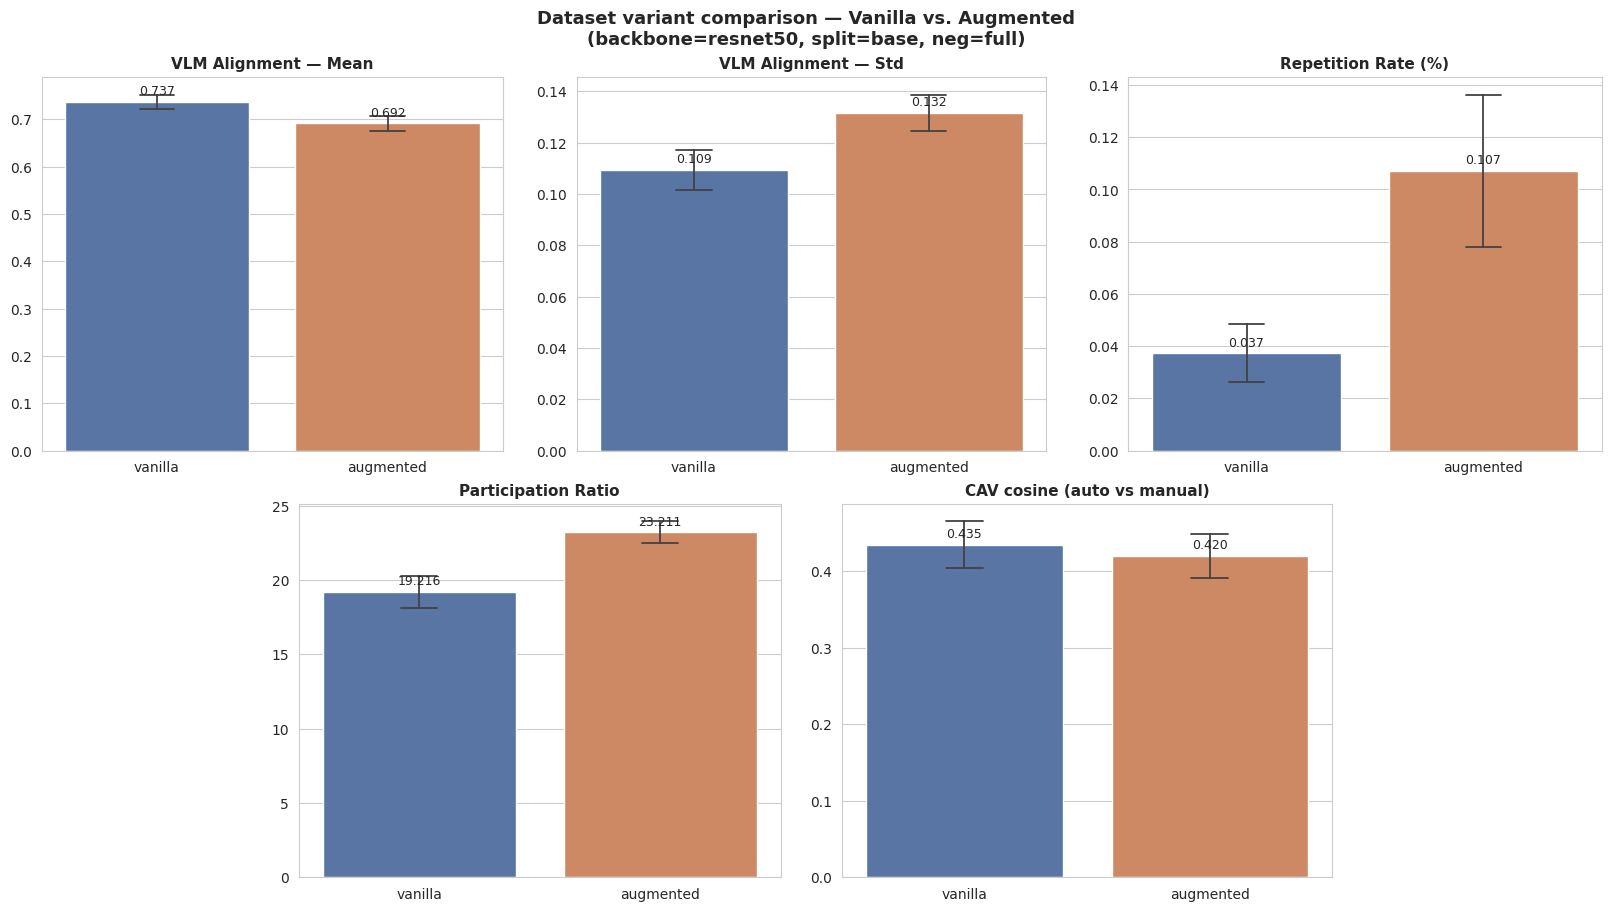

Saved fig1_vanilla_vs_augmented.png


In [78]:
sns.set_style('whitegrid')
src_palette = {'vanilla': '#4C72B0', 'augmented': '#DD8452'}

fig, axes = grid_centered(len(METRICS), ncols=3, figsize=(16, 9))
for ax, (col, label) in zip(axes, METRICS):
    sns.barplot(data=df, x='source', y=col, order=cfg.auto_sources,
                hue='source', hue_order=cfg.auto_sources, palette=src_palette,
                legend=False, errorbar='se', capsize=0.15,
                err_kws={'linewidth': 1.3}, ax=ax)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    for cont in ax.containers:
        ax.bar_label(cont, fmt='%.3f', padding=3, fontsize=9)

fig.suptitle(f'Dataset variant comparison — Vanilla vs. Augmented\n'
             f'(backbone={cfg.model_name}, split={cfg.split}, '
             f'neg={cfg.negative_kind})', fontsize=13, fontweight='bold')
fig.savefig(f'{cfg.output_dir}/fig1_vanilla_vs_augmented.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved fig1_vanilla_vs_augmented.png')

## Figure 2 — Cropping policies
One panel per metric; bars are the four crop policies, grouped by source.
Aggregated over concepts; error bars = standard error.

AttributeError: 'list' object has no attribute 'flat'

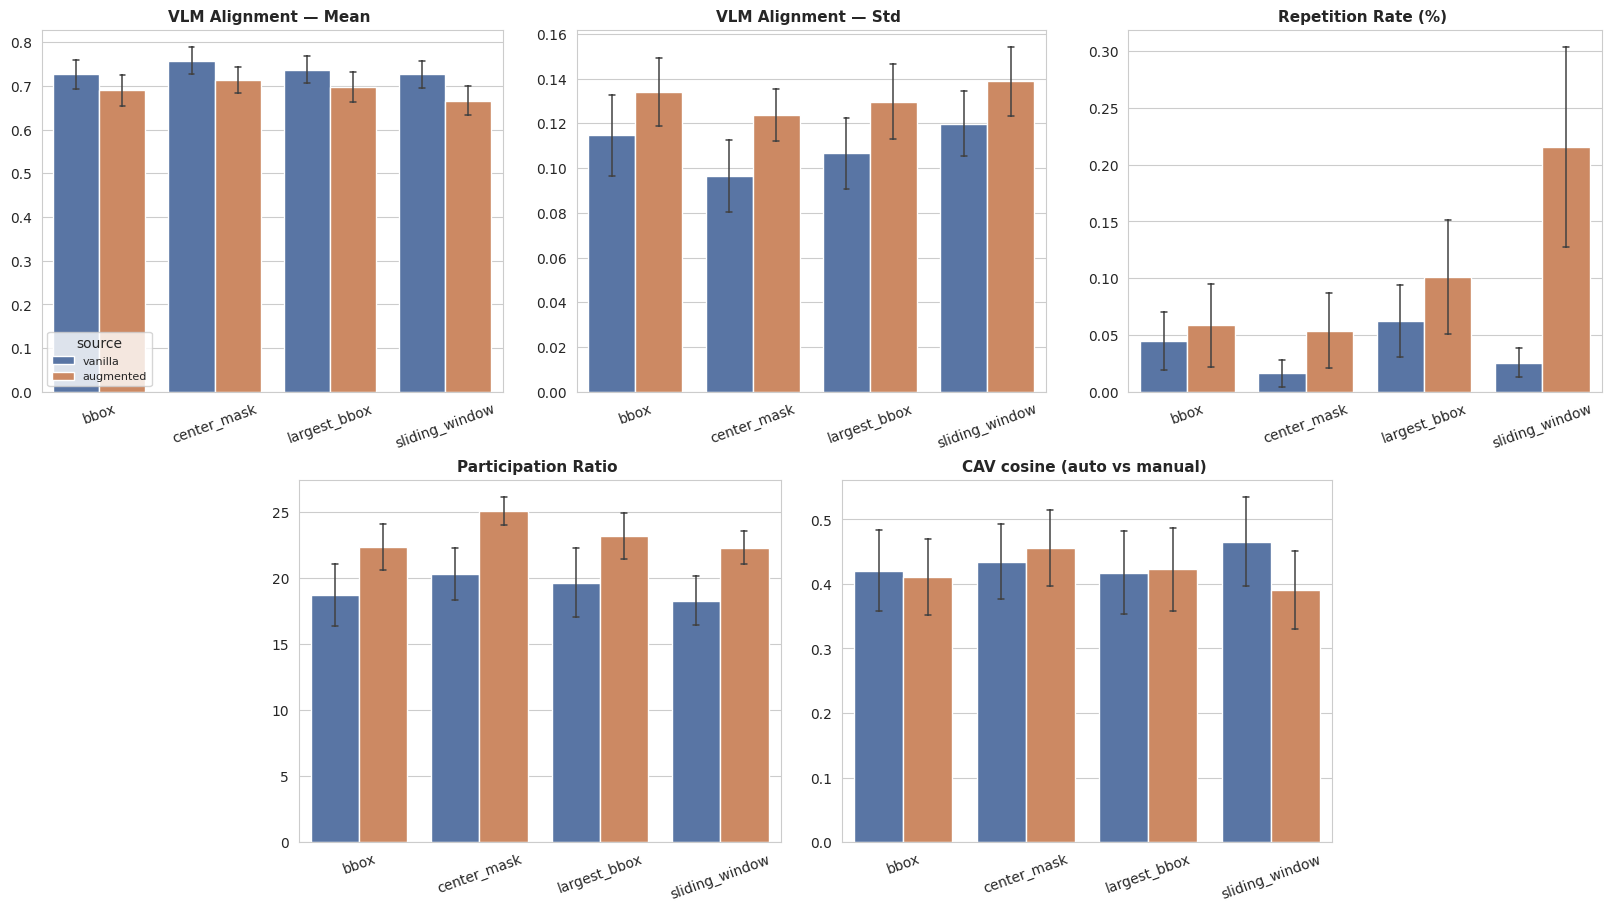

In [82]:
fig, axes = grid_centered(len(METRICS), ncols=3, figsize=(16, 9))

for ax, (col, label) in zip(axes, METRICS):
    sns.barplot(data=df, x='crop_method', y=col, order=cfg.crop_methods,
                hue='source', hue_order=cfg.auto_sources, palette=src_palette,
                errorbar='se', capsize=0.1, err_kws={'linewidth': 1.1}, ax=ax)
    ax.set_title(f'{label} ', fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    if ax is not axes[0]:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    else:
        ax.legend(fontsize=8, title='source')

for ax in axes.flat[len(METRICS):]:
    ax.set_visible(False)

fig.suptitle(f'Cropping-policy comparison\n'
             f'(backbone={cfg.model_name}, split={cfg.split}, '
             f'neg={cfg.negative_kind})', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{cfg.output_dir}/fig2_cropping_policies.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved fig2_cropping_policies.png')


## Export — long-format CSVs

In [ ]:
p_cells = f'{cfg.output_dir}/summary_metrics_cells.csv'
p_layer = f'{cfg.output_dir}/summary_metrics_layers.csv'
p_src = f'{cfg.output_dir}/summary_by_source.csv'
p_crop = f'{cfg.output_dir}/summary_by_crop.csv'
df.to_csv(p_cells, index=False)
df_layer.to_csv(p_layer, index=False)
summary_source.to_csv(p_src)
summary_crop.to_csv(p_crop)
print('Saved:')
for p in (p_cells, p_layer, p_src, p_crop):
    print('  ', p)
df.describe(include='all')